# Customer Analysis for Business Decision Making

This project analyzes customer data to answer key business questions for an e-commerce company.

## Business Questions

- Who are the most valuable customers?
- Which customers are at risk of churning?
- Which city is the best target for marketing?
- Were discounts effective?
- What actions can increase sales?

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("default")

# Project Color Palette
PRIMARY_COLOR = "forestgreen"
SECONDARY_COLOR = "mediumseagreen"
ACCENT_COLOR = "darkgreen"

# Load Dataset

Load the cleaned customer dataset into a pandas DataFrame.

In [49]:
df = pd.read_excel("../data/cleaned_dataset_nargessabbagh.xlsx")

df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


# Dataset Overview

Explore the dataset structure before starting the analysis.

In [50]:
df.shape

(60, 17)

In [51]:
df.columns

Index(['customer_id', 'first_name', 'gender', 'age', 'city', 'province',
       'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value',
       'total_spending', 'last_purchase_days', 'payment_method', 'device',
       'discount_used', 'returned_items', 'satisfaction_score'],
      dtype='str')

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     str           
 2   gender              60 non-null     str           
 3   age                 60 non-null     int64         
 4   city                60 non-null     str           
 5   province            60 non-null     str           
 6   signup_date         60 non-null     datetime64[us]
 7   membership_tier     60 non-null     str           
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     str           
 13  device              60 non-null     str           
 14  discoun

In [53]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
customer_id,60.0,1030.5,1001.0,1015.75,1030.5,1045.25,1060.0,17.464249
age,60.0,43.7,19.0,31.75,45.0,58.0,65.0,13.946994
signup_date,60,2023-02-03 14:00:00,2021-02-23 00:00:00,2021-12-06 12:00:00,2022-08-15 00:00:00,2024-06-14 12:00:00,2025-09-09 00:00:00,NaN
purchase_count,60.0,17.383333,0.0,10.75,17.0,24.5,35.0,10.14988
avg_order_value,60.0,213.1565,27.63,108.1375,165.435,324.1075,449.81,130.509923
total_spending,60.0,3366.428833,0.0,1167.035,2128.69,4213.1175,14354.34,3235.132979
last_purchase_days,60.0,198.6,3.0,134.25,203.0,273.75,365.0,97.843043
returned_items,60.0,3.8,0.0,1.0,3.5,6.0,8.0,2.666808
satisfaction_score,60.0,2.983333,1.0,2.0,3.0,4.0,5.0,1.431979


# Data Validation

Verify that the dataset is clean and ready for analysis.

In [54]:
df.isnull().sum()

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.dtypes

customer_id                    int64
first_name                       str
gender                           str
age                            int64
city                             str
province                         str
signup_date           datetime64[us]
membership_tier                  str
purchase_count                 int64
avg_order_value              float64
total_spending               float64
last_purchase_days             int64
payment_method                   str
device                           str
discount_used                    str
returned_items                 int64
satisfaction_score             int64
dtype: object

# Exploratory Data Analysis (EDA)

Explore the dataset to understand customer behavior and business patterns before answering the business questions.

## General Exploration

In this section, we explore the overall characteristics of the dataset before answering the business questions.

In [57]:
df["gender"].value_counts()

gender
M    35
F    25
Name: count, dtype: int64

In [58]:
df["membership_tier"].value_counts()

membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

In [59]:
df["city"].value_counts()

city
Tabriz     12
Mashhad    11
Ahvaz       8
Karaj       7
Tehran      6
Shiraz      6
Isfahan     5
Rasht       5
Name: count, dtype: int64

In [60]:
df["payment_method"].value_counts()

payment_method
Online Wallet    23
Cash             19
Card             18
Name: count, dtype: int64

In [61]:
df["device"].value_counts()

device
Android    22
Web        20
iPhone     18
Name: count, dtype: int64

In [62]:
df[
    [
        "age",
        "purchase_count",
        "avg_order_value",
        "total_spending",
        "last_purchase_days",
        "returned_items",
        "satisfaction_score",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
age,60.0,43.700000,13.946994,19.00,31.7500,45.000,58.0000,65.00
purchase_count,60.0,17.383333,10.149880,0.00,10.7500,17.000,24.5000,35.00
avg_order_value,60.0,213.156500,130.509923,27.63,108.1375,165.435,324.1075,449.81
total_spending,60.0,3366.428833,3235.132979,0.00,1167.0350,2128.690,4213.1175,14354.34
last_purchase_days,60.0,198.600000,97.843043,3.00,134.2500,203.000,273.7500,365.00
returned_items,60.0,3.800000,2.666808,0.00,1.0000,3.500,6.0000,8.00
satisfaction_score,60.0,2.983333,1.431979,1.00,2.0000,3.000,4.0000,5.00


### EDA Summary

The dataset appears to be clean and well-structured.

Initial exploration shows a balanced distribution across customer demographics, membership levels, payment methods, and devices. No missing values or duplicate records were found during the validation process.

These findings provide a solid foundation for answering the business questions.


# Business Question 1: Who Are the Most Valuable Customers?

In this section, we identify the most valuable customers based on their purchasing behavior.

Our primary criterion is the number of purchases (`purchase_count`), as it reflects customer loyalty. As a secondary criterion, we consider the total amount spent (`total_spending`).

In [63]:
top_customers = df.sort_values(
    by=["purchase_count", "total_spending"],
    ascending=[False, False]
)

top_customers.head(10)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
5,1006,Amir,M,58,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
8,1009,Kimia,F,61,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
39,1040,Amir,M,65,Tehran,Tehran,2021-11-02,Bronze,34,37.66,1280.44,126,Card,Android,Yes,3,2
43,1044,Mina,F,64,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,No,7,2
56,1057,Maryam,F,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4
58,1059,Ali,M,57,Isfahan,Isfahan,2023-09-05,Gold,31,287.05,8898.55,224,Online Wallet,iPhone,Yes,0,5
22,1023,Ali,M,50,Mashhad,Khorasan,2024-05-02,Bronze,31,124.24,3851.44,170,Card,Web,No,2,4
13,1014,Reza,M,35,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4
37,1038,Amir,M,45,Mashhad,Khorasan,2022-08-05,Bronze,31,27.63,856.53,201,Online Wallet,Web,Yes,1,4
49,1050,Reza,M,48,Mashhad,Khorasan,2023-08-04,Bronze,30,206.60,6198.00,205,Cash,Android,Yes,2,2


### Top 10 Valuable Customers

The following chart shows the top 10 customers ranked by purchase count and total spending.

In [64]:
top10 = top_customers.head(10).copy()

top10["customer_label"] = (
    top10["customer_id"].astype(str)
    + " - "
    + top10["first_name"]
)

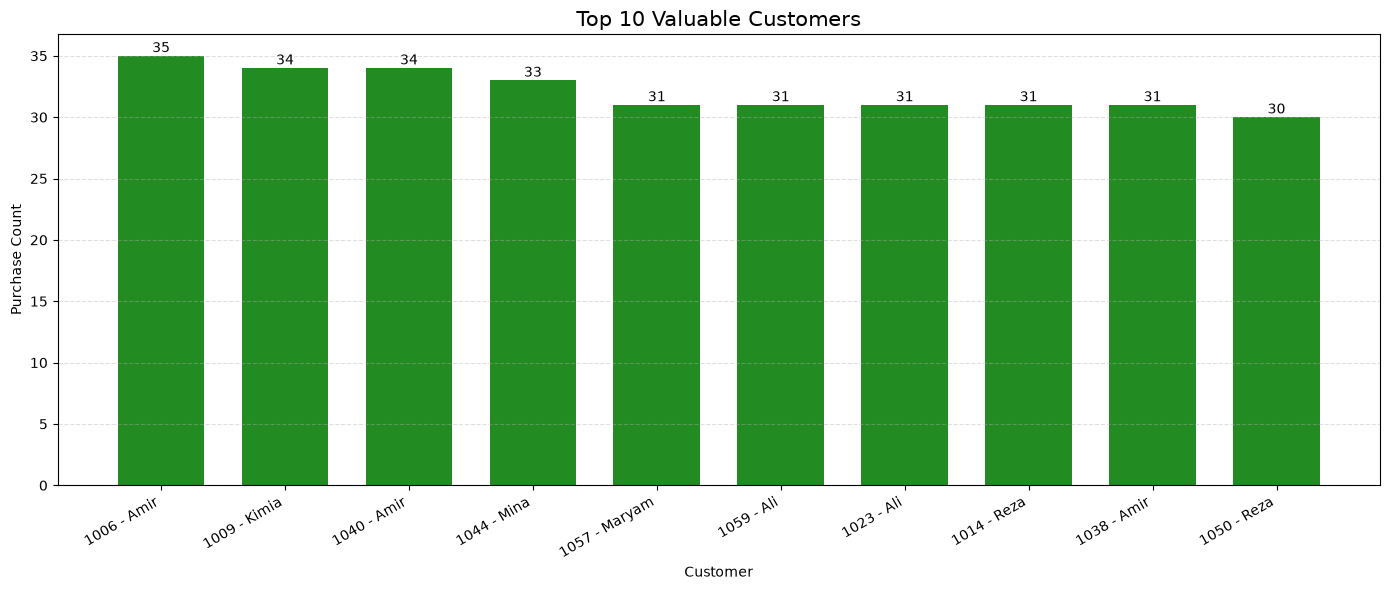

In [65]:
plt.figure(figsize=(14, 6))

bars = plt.bar(
    top10["customer_label"],
    top10["purchase_count"],
    color=PRIMARY_COLOR,
    width=0.7   # پهنای میله‌ها
)

plt.title("Top 10 Valuable Customers", fontsize=15)
plt.xlabel("Customer")
plt.ylabel("Purchase Count")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Characteristics of Valuable Customers

After identifying the top customers, we analyze their common characteristics to better understand what makes them valuable.

In [66]:
top10[
    [
        "customer_id",
        "first_name",
        "membership_tier",
        "city",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
]

,customer_id,first_name,membership_tier,city,purchase_count,total_spending,last_purchase_days,satisfaction_score
5,1006,Amir,Gold,Mashhad,35,3868.55,205,2
8,1009,Kimia,Silver,Karaj,34,11615.42,232,2
39,1040,Amir,Bronze,Tehran,34,1280.44,126,2
43,1044,Mina,Gold,Shiraz,33,14354.34,165,2
56,1057,Maryam,Bronze,Ahvaz,31,13532.74,82,4
58,1059,Ali,Gold,Isfahan,31,8898.55,224,5
22,1023,Ali,Bronze,Mashhad,31,3851.44,170,4
13,1014,Reza,VIP,Tabriz,31,3353.89,97,4
37,1038,Amir,Bronze,Mashhad,31,856.53,201,4
49,1050,Reza,Bronze,Mashhad,30,6198.00,205,2


In [67]:
top10["membership_tier"].value_counts()

membership_tier
Bronze    5
Gold      3
Silver    1
VIP       1
Name: count, dtype: int64

In [68]:
top10["city"].value_counts()

city
Mashhad    4
Karaj      1
Tehran     1
Shiraz     1
Ahvaz      1
Isfahan    1
Tabriz     1
Name: count, dtype: int64

In [69]:
top10["satisfaction_score"].mean()

np.float64(3.1)

### Insight

Customers with high purchase frequency also contribute significantly to total revenue.

These customers represent the company's core customer base and should be prioritized through loyalty programs and personalized marketing strategies.

# Business Question 2: Which Customers Are at Risk of Churning?

Customers who have not purchased for a long period are more likely to churn. We identify these customers using the number of days since their last purchase and then examine additional factors such as customer satisfaction and returned items.

In [70]:
churn_risk = df.sort_values(
    by="last_purchase_days",
    ascending=False
)

churn_risk.head(10)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
34,1035,Arash,M,58,Tabriz,East Azerbaijan,2022-05-15,Bronze,17,348.13,5918.21,365,Cash,Android,No,5,3
48,1049,Ali,M,32,Mashhad,Khorasan,2023-01-02,Gold,23,93.06,2140.38,357,Card,Web,No,1,1
41,1042,Sina,M,43,Ahvaz,Khuzestan,2021-12-25,Gold,12,48.06,576.72,350,Online Wallet,Android,Yes,5,5
29,1030,Sina,M,60,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,4079.14,340,Cash,Web,Yes,4,4
57,1058,Amir,M,47,Tehran,Tehran,2024-09-27,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,No,0,2
15,1016,Neda,F,45,Shiraz,Fars,2024-09-04,Bronze,11,136.17,1497.87,333,Online Wallet,Android,Yes,3,2
52,1053,Sina,M,32,Tehran,Tehran,2021-11-08,Gold,18,322.53,5805.54,320,Online Wallet,Web,Yes,6,1
28,1029,Ali,M,34,Tabriz,East Azerbaijan,2023-07-03,Gold,2,323.32,646.64,319,Cash,Web,Yes,2,5
24,1025,Neda,F,41,Mashhad,Khorasan,2021-06-25,VIP,2,406.03,812.06,317,Online Wallet,Android,Yes,2,2
18,1019,Neda,F,22,Shiraz,Fars,2021-10-08,Bronze,4,308.72,1234.88,317,Card,iPhone,No,4,2


### Analyzing Churn Risk Factors

We now examine whether at-risk customers have low satisfaction scores or a high number of returned items.

In [71]:
churn_risk.head(10)[
    [
        "customer_id",
        "first_name",
        "last_purchase_days",
        "purchase_count",
        "returned_items",
        "satisfaction_score",
    ]
]

,customer_id,first_name,last_purchase_days,purchase_count,returned_items,satisfaction_score
34,1035,Arash,365,17,5,3
48,1049,Ali,357,23,1,1
41,1042,Sina,350,12,5,5
29,1030,Sina,340,26,4,4
57,1058,Amir,336,5,0,2
15,1016,Neda,333,11,3,2
52,1053,Sina,320,18,6,1
28,1029,Ali,319,2,2,5
24,1025,Neda,317,2,2,2
18,1019,Neda,317,4,4,2


In [72]:
churn_risk.head(10)["satisfaction_score"].mean()

np.float64(2.7)

In [73]:
churn_risk.head(10)["returned_items"].mean()

np.float64(3.2)

In [74]:
df["last_purchase_days"].describe()

count     60.000000
mean     198.600000
std       97.843043
min        3.000000
25%      134.250000
50%      203.000000
75%      273.750000
max      365.000000
Name: last_purchase_days, dtype: float64

### Identifying Customers at Risk of Churn

Customers whose last purchase was more than 273 days ago are classified as being at risk of churn.

In [75]:
df["churn_risk"] = np.where(
    df["last_purchase_days"] > 273,
    "At Risk",
    "Active"
)

df[["customer_id", "last_purchase_days", "churn_risk"]].head()

,customer_id,last_purchase_days,churn_risk
0,1001,16,Active
1,1002,3,Active
2,1003,22,Active
3,1004,40,Active
4,1005,273,Active


In [76]:
df["churn_risk"].value_counts()

churn_risk
Active     45
At Risk    15
Name: count, dtype: int64

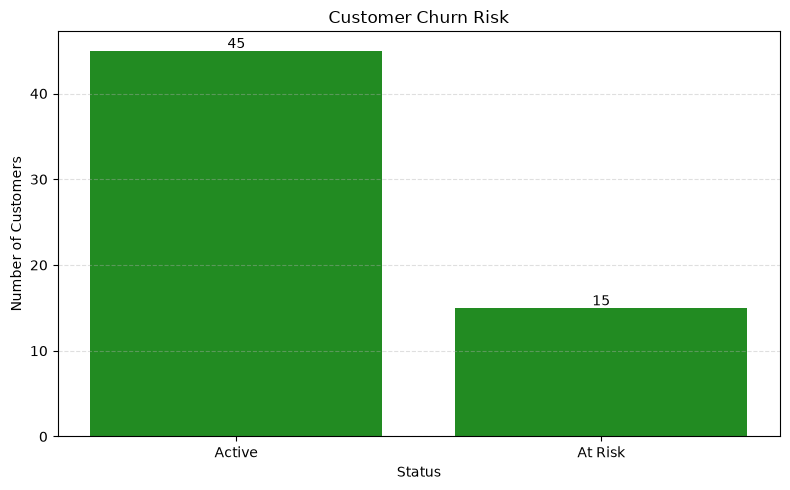

In [77]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    df["churn_risk"].value_counts().index,
    df["churn_risk"].value_counts().values,
    color=PRIMARY_COLOR
)

plt.title("Customer Churn Risk")
plt.xlabel("Status")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha="center"
    )

plt.tight_layout()
plt.show()

### Comparing Active and At-Risk Customers

To better understand customer churn, we compare active customers with at-risk customers using satisfaction score, returned items, purchase count, and total spending.

In [78]:
df.groupby("churn_risk")[
    [
        "purchase_count",
        "total_spending",
        "returned_items",
        "satisfaction_score",
    ]
].mean().round(2)

,purchase_count,total_spending,returned_items,satisfaction_score
churn_risk,,,,
Active,18.60,3627.29,3.84,3.13
At Risk,13.73,2583.85,3.67,2.53


In [79]:
at_risk = df[df["churn_risk"] == "At Risk"]

at_risk.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,churn_risk
6,1007,Reza,M,43,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5,At Risk
9,1010,Arash,M,45,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1,At Risk
15,1016,Neda,F,45,Shiraz,Fars,2024-09-04,Bronze,11,136.17,1497.87,333,Online Wallet,Android,Yes,3,2,At Risk
18,1019,Neda,F,22,Shiraz,Fars,2021-10-08,Bronze,4,308.72,1234.88,317,Card,iPhone,No,4,2,At Risk
23,1024,Sina,M,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.00,298,Online Wallet,Android,No,0,1,At Risk


In [80]:
at_risk.sort_values(
    by="returned_items",
    ascending=False
).head(10)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,churn_risk
9,1010,Arash,M,45,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1,At Risk
53,1054,Reza,M,59,Tabriz,East Azerbaijan,2021-03-26,Gold,9,410.16,3691.44,304,Online Wallet,Web,No,7,1,At Risk
33,1034,Maryam,F,25,Tabriz,East Azerbaijan,2024-10-27,VIP,29,73.00,2117.00,280,Cash,Android,No,7,3,At Risk
52,1053,Sina,M,32,Tehran,Tehran,2021-11-08,Gold,18,322.53,5805.54,320,Online Wallet,Web,Yes,6,1,At Risk
34,1035,Arash,M,58,Tabriz,East Azerbaijan,2022-05-15,Bronze,17,348.13,5918.21,365,Cash,Android,No,5,3,At Risk
41,1042,Sina,M,43,Ahvaz,Khuzestan,2021-12-25,Gold,12,48.06,576.72,350,Online Wallet,Android,Yes,5,5,At Risk
18,1019,Neda,F,22,Shiraz,Fars,2021-10-08,Bronze,4,308.72,1234.88,317,Card,iPhone,No,4,2,At Risk
29,1030,Sina,M,60,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,4079.14,340,Cash,Web,Yes,4,4,At Risk
15,1016,Neda,F,45,Shiraz,Fars,2024-09-04,Bronze,11,136.17,1497.87,333,Online Wallet,Android,Yes,3,2,At Risk
24,1025,Neda,F,41,Mashhad,Khorasan,2021-06-25,VIP,2,406.03,812.06,317,Online Wallet,Android,Yes,2,2,At Risk


In [81]:
at_risk.sort_values(
    by="satisfaction_score"
).head(10)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,churn_risk
9,1010,Arash,M,45,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1,At Risk
23,1024,Sina,M,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.00,298,Online Wallet,Android,No,0,1,At Risk
52,1053,Sina,M,32,Tehran,Tehran,2021-11-08,Gold,18,322.53,5805.54,320,Online Wallet,Web,Yes,6,1,At Risk
48,1049,Ali,M,32,Mashhad,Khorasan,2023-01-02,Gold,23,93.06,2140.38,357,Card,Web,No,1,1,At Risk
53,1054,Reza,M,59,Tabriz,East Azerbaijan,2021-03-26,Gold,9,410.16,3691.44,304,Online Wallet,Web,No,7,1,At Risk
24,1025,Neda,F,41,Mashhad,Khorasan,2021-06-25,VIP,2,406.03,812.06,317,Online Wallet,Android,Yes,2,2,At Risk
18,1019,Neda,F,22,Shiraz,Fars,2021-10-08,Bronze,4,308.72,1234.88,317,Card,iPhone,No,4,2,At Risk
15,1016,Neda,F,45,Shiraz,Fars,2024-09-04,Bronze,11,136.17,1497.87,333,Online Wallet,Android,Yes,3,2,At Risk
57,1058,Amir,M,47,Tehran,Tehran,2024-09-27,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,No,0,2,At Risk
33,1034,Maryam,F,25,Tabriz,East Azerbaijan,2024-10-27,VIP,29,73.00,2117.00,280,Cash,Android,No,7,3,At Risk


### Comparison of Customer Metrics

The following charts compare key customer metrics between active customers and customers at risk of churn.

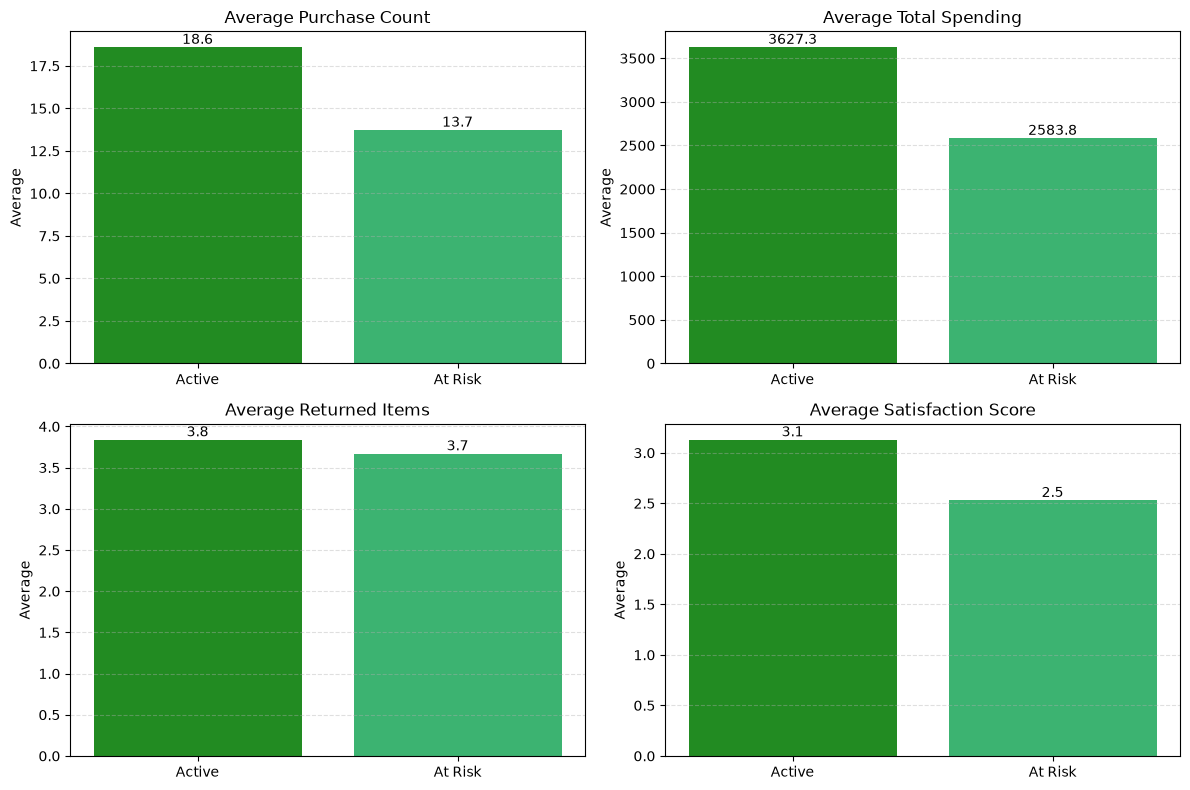

In [86]:
comparison = df.groupby("churn_risk")[
    [
        "purchase_count",
        "total_spending",
        "returned_items",
        "satisfaction_score",
    ]
].mean().round(2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = [
    "purchase_count",
    "total_spending",
    "returned_items",
    "satisfaction_score",
]

titles = [
    "Average Purchase Count",
    "Average Total Spending",
    "Average Returned Items",
    "Average Satisfaction Score",
]

colors = [PRIMARY_COLOR, SECONDARY_COLOR]

for ax, metric, title in zip(axes.flat, metrics, titles):

    bars = ax.bar(
        comparison.index,
        comparison[metric],
        color=colors
    )

    ax.set_title(title)
    ax.set_ylabel("Average")

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

### Insight

At-risk customers purchase less frequently and spend less money than active customers.

They also return more products and report lower satisfaction scores, indicating that negative shopping experiences may contribute to customer churn.

# Business Question 3: Which Cities Are Best for Marketing?

We analyze customer activity across different cities to identify the most promising markets for future marketing campaigns.

The analysis considers customer count, purchase activity, total spending, and average spending per customer.

In [ ]:
city_analysis = (
    df.groupby("city")
    .agg(
        customer_count=("customer_id", "nunique"),
        total_purchases=("purchase_count", "sum"),
        total_spending=("total_spending", "sum"),
    )
)

In [ ]:
city_analysis["avg_spending_per_customer"] = (
    city_analysis["total_spending"]
    / city_analysis["customer_count"]
).round(2)

In [ ]:
city_analysis = city_analysis.sort_values(
    by="total_spending",
    ascending=False
)

city_analysis

,customer_count,total_purchases,total_spending,avg_spending_per_customer
city,,,,
Mashhad,11,249,43197.58,3927.05
Tabriz,12,189,36192.49,3016.04
Karaj,7,112,26189.81,3741.40
Ahvaz,8,111,23384.78,2923.10
Isfahan,5,99,21975.32,4395.06
Shiraz,6,98,20715.92,3452.65
Rasht,5,82,15168.54,3033.71
Tehran,6,103,15161.29,2526.88


### Top Cities by Total Spending

This chart shows which cities generate the highest revenue for the company. These cities represent the strongest current markets and are important for maintaining sales performance.

In [ ]:
top_spending = city_analysis.sort_values(
    by="total_spending",
    ascending=False
)

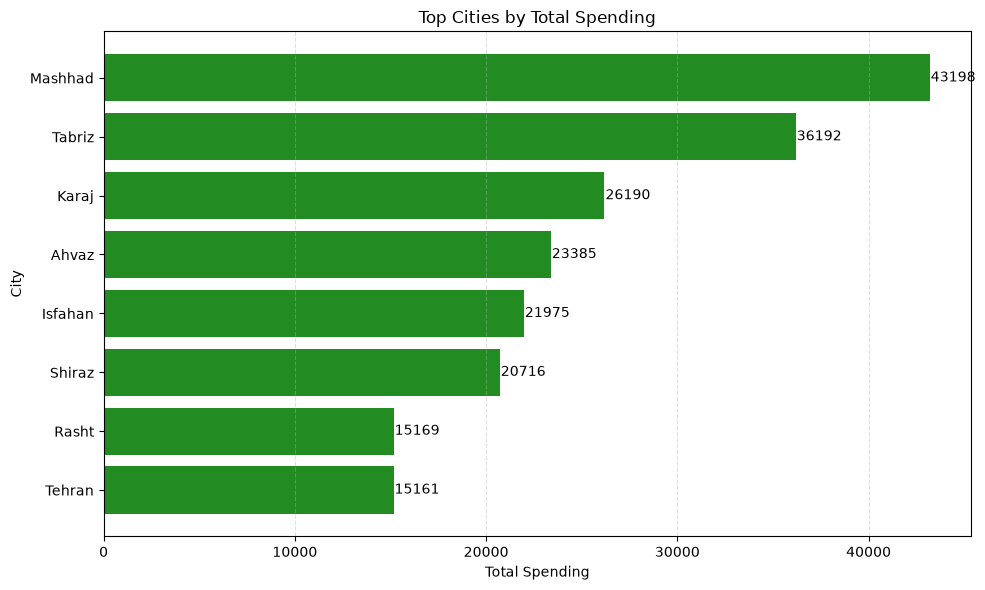

In [ ]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_spending.index,
    top_spending["total_spending"],
    color=PRIMARY_COLOR
)

plt.title("Top Cities by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Average Spending per Customer

This chart compares the average spending per customer across cities. Cities with higher averages may represent valuable opportunities for targeted marketing campaigns.

In [ ]:
top_average = city_analysis.sort_values(
    by="avg_spending_per_customer",
    ascending=False
)

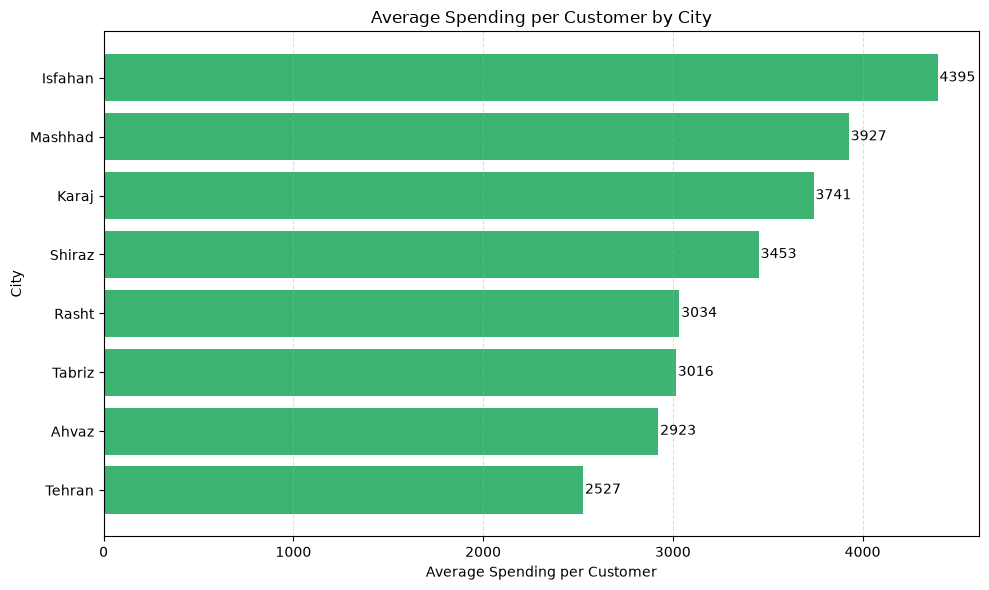

In [ ]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_average.index,
    top_average["avg_spending_per_customer"],
    color=SECONDARY_COLOR
)

plt.title("Average Spending per Customer by City")
plt.xlabel("Average Spending per Customer")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Insight

Tehran generates the highest total revenue, making it the company's strongest existing market. Retaining customers in this city should remain a top priority.

Karaj has the highest average spending per customer, indicating strong growth potential. Acquiring more customers in this city could significantly increase overall revenue.

Cities such as Shiraz, Tabriz, and Isfahan also perform well and should be considered for future marketing campaigns based on both market size and customer value.

# Business Question 4: Are Discounts Really Effective?

This analysis evaluates whether customers who used discounts behave differently from those who did not.

We compare purchase activity, total spending, and customer satisfaction to assess the impact of discounts on business performance.

In [ ]:
df["discount_used"].value_counts()

discount_used
No     34
Yes    26
Name: count, dtype: int64

In [ ]:
discount_analysis = (
    df.groupby("discount_used")
    .agg(
        avg_purchase_count=("purchase_count", "mean"),
        avg_total_spending=("total_spending", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
    )
    .round(2)
)

discount_analysis

,avg_purchase_count,avg_total_spending,avg_satisfaction
discount_used,,,
No,17.29,3736.74,2.76
Yes,17.50,2882.17,3.27


### Discount Impact Analysis

The following comparison examines whether customers who used discounts differ from those who did not in terms of purchasing behavior and satisfaction.

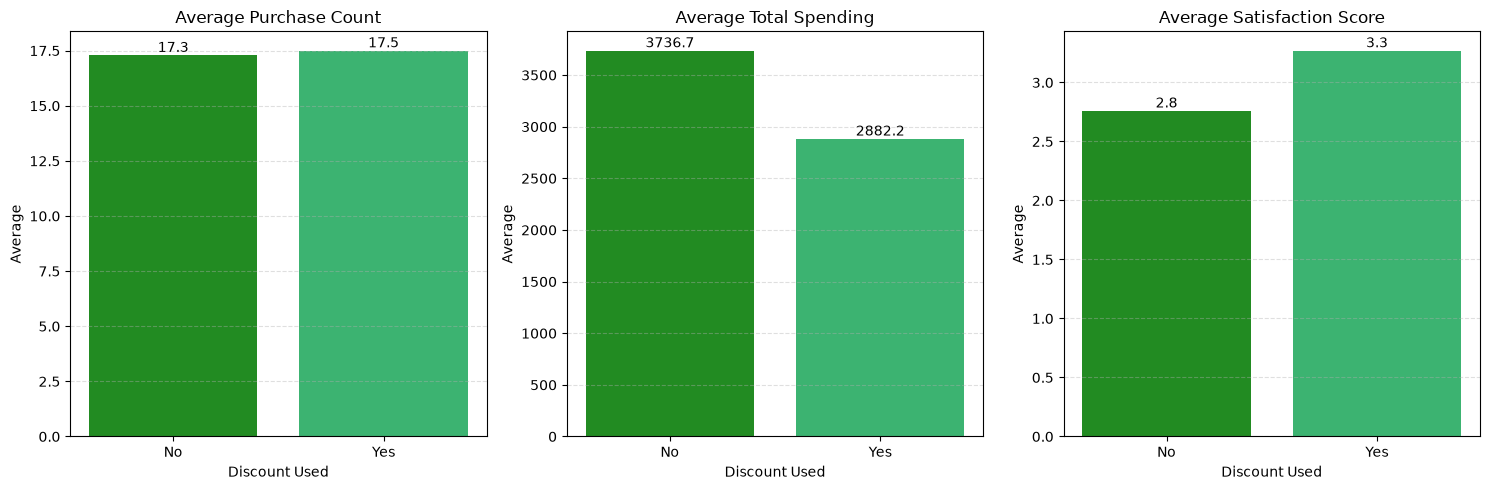

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    "avg_purchase_count",
    "avg_total_spending",
    "avg_satisfaction",
]

titles = [
    "Average Purchase Count",
    "Average Total Spending",
    "Average Satisfaction Score",
]

for ax, metric, title in zip(axes, metrics, titles):

    bars = ax.bar(
        discount_analysis.index,
        discount_analysis[metric],
        color=[PRIMARY_COLOR, SECONDARY_COLOR]
    )

    ax.set_title(title)
    ax.set_xlabel("Discount Used")
    ax.set_ylabel("Average")

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

### Insight

The analysis shows that discount usage has little impact on the average number of purchases, as both customer groups have similar purchase frequencies.

Interestingly, customers who did not use discounts spent more on average, suggesting that discounts did not increase overall spending in this dataset.

However, customers who used discounts reported higher satisfaction scores. This indicates that discounts may improve customer experience, even if they do not directly increase revenue.

# Final Business Recommendations

The following recommendations are directly derived from the findings of this analysis.

## 1. Focus on Retaining Valuable Customers

High-value customers generate the largest share of revenue. The company should strengthen loyalty programs, provide personalized offers, and reward repeat customers to increase long-term retention.

---

## 2. Invest in High-Potential Cities

Marketing efforts should prioritize cities such as Tehran, Karaj, Shiraz, Isfahan, and Tabriz. These cities either generate high total revenue or have customers with high average spending.

---

## 3. Use Discounts Strategically

The analysis suggests that discounts improve customer satisfaction but do not significantly increase purchase frequency or total spending. Therefore, discounts should be targeted toward new customers, at-risk customers, or seasonal campaigns instead of being offered to everyone.

# Conclusion

This project analyzed customer behavior using Python and data visualization to answer four key business questions.

The findings identified valuable customers, customers at risk of churn, high-performing cities, and the impact of discounts. Based on these insights, three practical business recommendations were proposed to support data-driven decision making.

This analysis demonstrates how customer data can support strategic business decisions using Python and data visualization.